In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
# load the dataset
df = pd.read_csv('/workspaces/youth-skills-data-insights/data/participants.csv')
# 1. Number of rows and columns
print("Dataset Shape:")
print(df.shape)

# 2. Column names
print("\nColumn names:")
print(df.columns.tolist())

# 3. Data types and Non null values 
print("\nDataset information:")
df.info()

# 4. Missing values 
print("\nMissing values:")
print(df.isnull().sum())

# 5. Duplicate rows
print("\nDuplicate rows")
print(df.duplicated().sum())

Dataset Shape:
(15, 12)

Column names:
['participant_id', 'name', 'age', 'gender', 'region', 'education', 'program', 'attendance_pct', 'pre_score', 'post_score', 'employment_status', 'satisfaction']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   participant_id     15 non-null     str  
 1   name               15 non-null     str  
 2   age                15 non-null     int64
 3   gender             15 non-null     str  
 4   region             15 non-null     str  
 5   education          15 non-null     str  
 6   program            15 non-null     str  
 7   attendance_pct     15 non-null     int64
 8   pre_score          15 non-null     int64
 9   post_score         15 non-null     int64
 10  employment_status  15 non-null     str  
 11  satisfaction       15 non-null     int64
dtypes: int64(5), str(7)
memory usage: 1.5 

In [22]:
# Check numerical ranges

print("\nAge range:")
print(df["age"].min(), "to", df["age"].max())

print("\nAttendance range:")
print(df["attendance_pct"].min(), "to", df["attendance_pct"].max())

print("\nPre-training score range:")
print(df["pre_score"].min(), "to", df["pre_score"].max())

print("\nPost-training score range:")
print(df["post_score"].min(), "to", df["post_score"].max())

print("\nSatisfaction range:")
print(df["satisfaction"].min(), "to", df["satisfaction"].max())

print("\nGender categories:")
print(df["gender"].unique())

print("\nRegion categories:")
print(df["region"].unique())

print("\nEducation categories:")
print(df["education"].unique())

print("\nProgram categories:")
print(df["program"].unique())

print("\nEmployment status categories:")
print(df["employment_status"].unique())


Age range:
21 to 31

Attendance range:
58 to 96

Pre-training score range:
39 to 63

Post-training score range:
51 to 88

Satisfaction range:
2 to 5

Gender categories:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Region categories:
<StringArray>
['Greater Accra', 'Ashanti', 'Central', 'Eastern', 'Western']
Length: 5, dtype: str

Education categories:
<StringArray>
['Tertiary', 'SHS']
Length: 2, dtype: str

Program categories:
<StringArray>
['Data Analytics', 'Web Development', 'Cybersecurity']
Length: 3, dtype: str

Employment status categories:
<StringArray>
['Employed', 'Unemployed']
Length: 2, dtype: str


In [23]:
# Calculate score improvement
df["score_improvement"] = df["post_score"]- df["pre_score"]

print("\n Score improvement:")
print(df[["participant_id", "pre_score", "post_score", "score_improvement"]])

# Calculate average improvement
average_improvement = df["score_improvement"].mean()

print("\nAverage score improvement:")
print(average_improvement)

# Calculate employment rate
employment_rate = ((df["employment_status"]=="Employed").mean() * 100)
print("\nEmployment rate:")
print(employment_rate)

# Calculate average attendance
average_attendance = df["attendance_pct"].mean()
print("\nAverage attendance:")
print(average_attendance)

# Calculate average satisfaction
average_satisfaction = df["satisfaction"].mean()
print("\nAverage satisfaction:")
print(average_satisfaction)


 Score improvement:
   participant_id  pre_score  post_score  score_improvement
0            P001         48          78                 30
1            P002         52          74                 22
2            P003         41          65                 24
3            P004         61          88                 27
4            P005         55          81                 26
5            P006         45          57                 12
6            P007         50          82                 32
7            P008         58          69                 11
8            P009         39          76                 37
9            P010         63          85                 22
10           P011         47          72                 25
11           P012         42          51                  9
12           P013         56          86                 30
13           P014         54          79                 25
14           P015         44          68                 24

Average score impr

In [24]:
# Compare programs
program_performance = df.groupby("program").agg(
    participants=("participant_id","count"),
    average_attendance=("attendance_pct","mean"),
    average_pre_score =("pre_score", "mean"),
    average_postscore=("post_score","mean"),
    average_improvement=("score_improvement","mean"),
    average_satisfaction=("satisfaction","mean")
)

print("\nProgram Performance:")
print(program_performance)


Program Performance:
                 participants  average_attendance  average_pre_score  \
program                                                                
Cybersecurity               4           84.750000               55.0   
Data Analytics              6           84.333333               50.5   
Web Development             5           80.600000               46.4   

                 average_postscore  average_improvement  average_satisfaction  
program                                                                        
Cybersecurity                 77.0                 22.0              4.000000  
Data Analytics                75.5                 25.0              4.333333  
Web Development               70.0                 23.6              4.000000  


In [25]:
#employment rate by program
employment_by_program = df.groupby("program")["employment_status"].apply(
    lambda x: (x == "Employed").mean()*100
)
print("\nEmployment rate by program:")
print(employment_by_program)

# Correlation between attendance and score improvement
attendance_improvement_corr = df["attendance_pct"].corr(df["score_improvement"])

print("\nAttendance vs score improvement correlation:")
print(attendance_improvement_corr)



Employment rate by program:
program
Cybersecurity      75.000000
Data Analytics     66.666667
Web Development    60.000000
Name: employment_status, dtype: float64

Attendance vs score improvement correlation:
0.8937066505625479


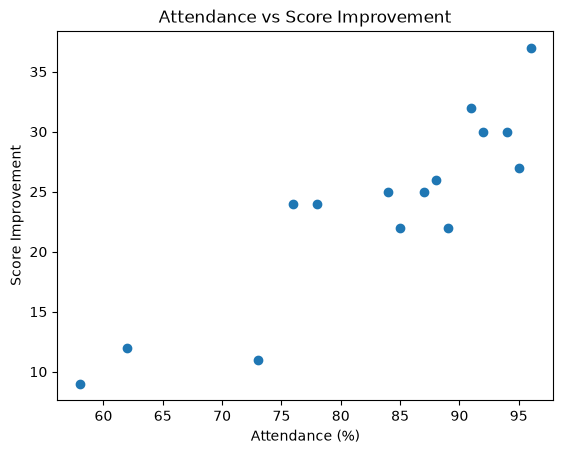

In [26]:
# Scatter plot: attendance vs score improvement
plt.scatter(df["attendance_pct"], df["score_improvement"])

plt.xlabel("Attendance (%)")
plt.ylabel("Score Improvement")
plt.title("Attendance vs Score Improvement")

plt.show()

In [27]:
employment_attendance = df.groupby("employment_status").agg(
    participants=("participant_id", "count"),
    average_attendance=("attendance_pct", "mean"),
    average_improvement=("score_improvement", "mean"),
    average_satisfaction=("satisfaction", "mean")
)

employment_attendance

,participants,average_attendance,average_improvement,average_satisfaction
employment_status,,,,
Employed,10,90.1,27.6,4.6
Unemployed,5,69.4,16.0,3.2


In [28]:
education_performance = df.groupby("education").agg(
    participants = ("participant_id","count"),
    average_attendance = ("attendance_pct","mean"),
    average_improvement=("score_improvement","mean"),
    average_satisfaction = ("satisfaction","mean")
)
education_performance

,participants,average_attendance,average_improvement,average_satisfaction
education,,,,
SHS,5,74.0,21.2,3.6
Tertiary,10,87.8,25.0,4.4


In [29]:
region_performance = df.groupby("region").agg(
    participants=("participant_id", "count"),
    average_attendance=("attendance_pct", "mean"),
    average_improvement=("score_improvement", "mean"),
    average_satisfaction=("satisfaction","mean")
).sort_values("average_improvement", ascending=False)

region_performance

,participants,average_attendance,average_improvement,average_satisfaction
region,,,,
Eastern,3,92.666667,29.666667,4.666667
Greater Accra,4,86.250000,25.500000,4.500000
Central,3,81.666667,21.666667,4.000000
Western,2,74.500000,20.500000,3.500000
Ashanti,3,77.000000,19.666667,3.666667


In [30]:
gender_performance = df.groupby("gender").agg(
    participants=("participant_id", "count"),
    average_attendance=("attendance_pct", "mean"),
    average_improvement=("score_improvement", "mean"),
    average_satisfaction=("satisfaction","mean")
)
gender_performance

,participants,average_attendance,average_improvement,average_satisfaction
gender,,,,
Female,8,87.375000,28.500000,4.625000
Male,7,78.428571,18.285714,3.571429


In [31]:
top_improvement = df[
    ["participant_id","name","program","attendance_pct",
     "pre_score","post_score","score_improvement","employment_status"]
].sort_values("score_improvement", ascending=False)

top_improvement

,participant_id,name,program,attendance_pct,pre_score,post_score,score_improvement,employment_status
8,P009,Ama Serwaa,Web Development,96,39,76,37,Employed
6,P007,Efua Addo,Data Analytics,91,50,82,32,Employed
0,P001,Akosua Mensah,Data Analytics,92,48,78,30,Employed
12,P013,Adjoa Nyarko,Data Analytics,94,56,86,30,Employed
3,P004,Kofi Mensah,Cybersecurity,95,61,88,27,Employed
4,P005,Abena Owusu,Web Development,88,55,81,26,Employed
13,P014,Samuel Tetteh,Cybersecurity,87,54,79,25,Employed
10,P011,Akua Sarpong,Cybersecurity,84,47,72,25,Employed
14,P015,Akosua Owusu,Web Development,76,44,68,24,Unemployed
2,P003,Adwoa Boateng,Data Analytics,78,41,65,24,Unemployed


In [32]:
df["performance_flag"] = np.where(
    (df["attendance_pct"] < 75) &
    (df["score_improvement"] < 15),
    "Needs Attention",
    "On Track"
)

df[
   ["participant_id","name","attendance_pct",
    "score_improvement","employment_status","performance_flag"] 
].sort_values("performance_flag")

,participant_id,name,attendance_pct,score_improvement,employment_status,performance_flag
5,P006,Yaw Ofori,62,12,Unemployed,Needs Attention
7,P008,Kojo Frimpong,73,11,Unemployed,Needs Attention
11,P012,Kwesi Antwi,58,9,Unemployed,Needs Attention
0,P001,Akosua Mensah,92,30,Employed,On Track
1,P002,Kwame Asare,85,22,Employed,On Track
2,P003,Adwoa Boateng,78,24,Unemployed,On Track
3,P004,Kofi Mensah,95,27,Employed,On Track
4,P005,Abena Owusu,88,26,Employed,On Track
6,P007,Efua Addo,91,32,Employed,On Track
8,P009,Ama Serwaa,96,37,Employed,On Track


In [33]:
performance_summary = df["performance_flag"].value_counts()

performance_percentage = (
    df["performance_flag"].value_counts(normalize=True) * 100
).round(2)

print("Participant count:")
display(performance_summary)

print("\nParticipant percentage:")
display(performance_percentage)

Participant count:


performance_flag
On Track           12
Needs Attention     3
Name: count, dtype: int64


Participant percentage:


performance_flag
On Track           80.0
Needs Attention    20.0
Name: proportion, dtype: float64

In [34]:
employment_by_education = df.groupby("education").agg(
    participants=("participant_id", "count"),
    employed=("employment_status", lambda x: (x == "Employed").sum()),
    employment_rate=("employment_status",
                      lambda x: (x == "Employed").mean() * 100)
)

employment_by_education

,participants,employed,employment_rate
education,,,
SHS,5,1,20.0
Tertiary,10,9,90.0


In [35]:
# Create headline KPIs for the dashboard

kpis = {
    "Total Participants": len(df),
    "Average Attendance (%)": round(df["attendance_pct"].mean(), 2),
    "Average Score Improvement": round(df["score_improvement"].mean(), 2),
    "Employment Rate (%)": round(
        (df["employment_status"] == "Employed").mean() * 100, 2
    ),
    "Average Satisfaction": round(df["satisfaction"].mean(), 2),
    "Needs Attention (%)": round(
        (df["performance_flag"] == "Needs Attention").mean() * 100, 2
    )
}

kpi_summary = pd.DataFrame(
    kpis.items(),
    columns=["KPI", "Value"]
)

kpi_summary

,KPI,Value
0,Total Participants,15.00
1,Average Attendance (%),83.20
2,Average Score Improvement,23.73
3,Employment Rate (%),66.67
4,Average Satisfaction,4.13
5,Needs Attention (%),20.00


In [36]:
# Calculate average learning improvement by training program
program_improvement = (
    df.groupby("program")["score_improvement"]
    .mean()
    .sort_values(ascending=False)
)

program_improvement

program
Data Analytics     25.0
Web Development    23.6
Cybersecurity      22.0
Name: score_improvement, dtype: float64

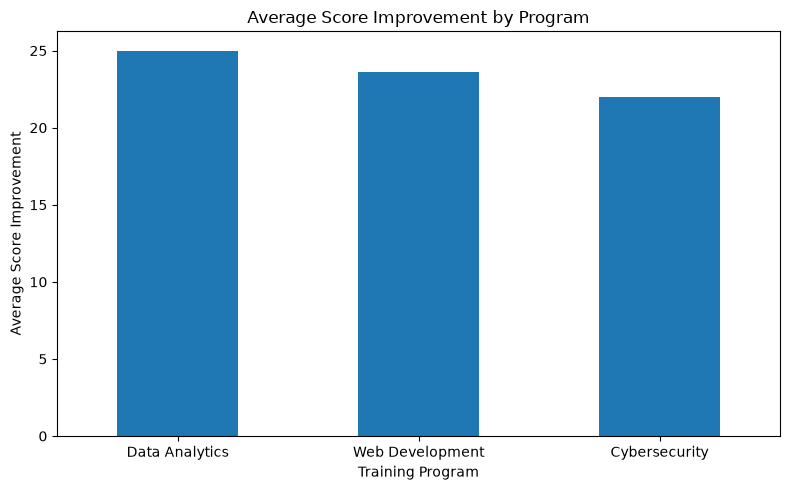

In [37]:
# Visualize average score improvement by program

plt.figure(figsize=(8, 5))

program_improvement.plot(kind="bar")

plt.title("Average Score Improvement by Program")
plt.xlabel("Training Program")
plt.ylabel("Average Score Improvement")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [38]:
# Calculate employment rate for each training program
program_employment = (
    df.groupby("program")["employment_status"]
    .apply(lambda x: (x == "Employed").mean() * 100)
    .sort_values(ascending=False)
)

program_employment

program
Cybersecurity      75.000000
Data Analytics     66.666667
Web Development    60.000000
Name: employment_status, dtype: float64

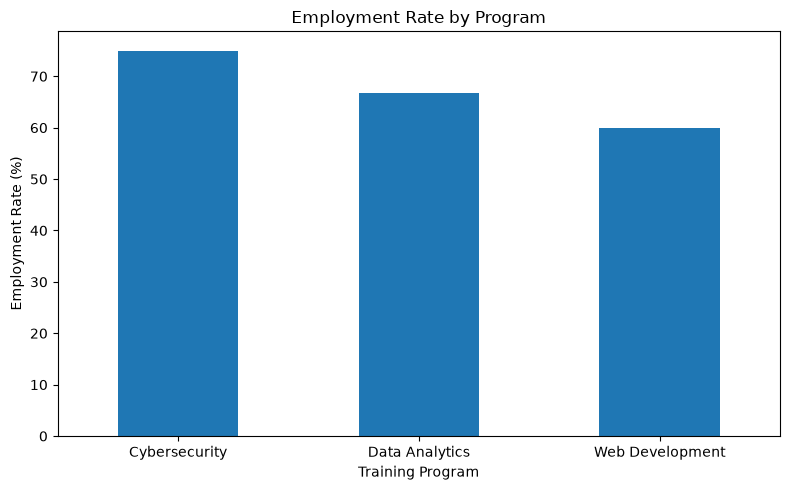

In [39]:
# Visualize employment rate by training program

plt.figure(figsize=(8, 5))

program_employment.plot(kind="bar")

plt.title("Employment Rate by Program")
plt.xlabel("Training Program")
plt.ylabel("Employment Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [41]:
# Compare average attendance between employment groups

employment_attendance_avg = (
    df.groupby("employment_status")["attendance_pct"]
    .mean()
    .sort_values(ascending=False)
)

employment_attendance_avg

employment_status
Employed      90.1
Unemployed    69.4
Name: attendance_pct, dtype: float64

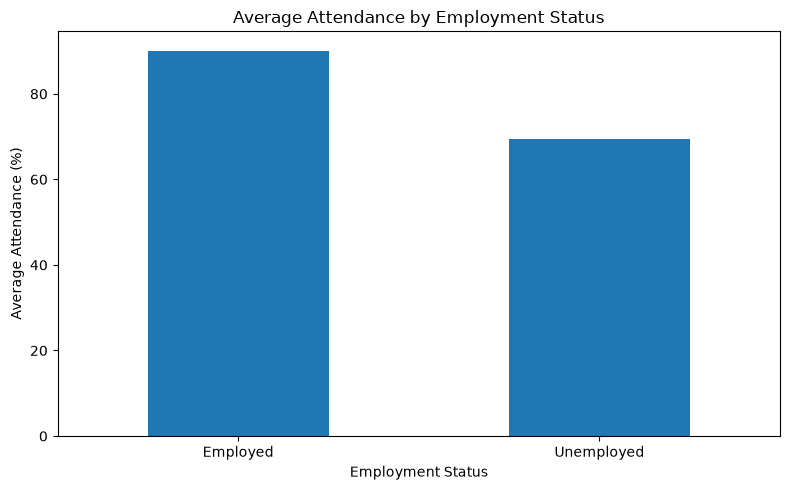

In [42]:
# Visualize average attendance by employment status

plt.figure(figsize=(8, 5))

employment_attendance_avg.plot(kind="bar")

plt.title("Average Attendance by Employment Status")
plt.xlabel("Employment Status")
plt.ylabel("Average Attendance (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

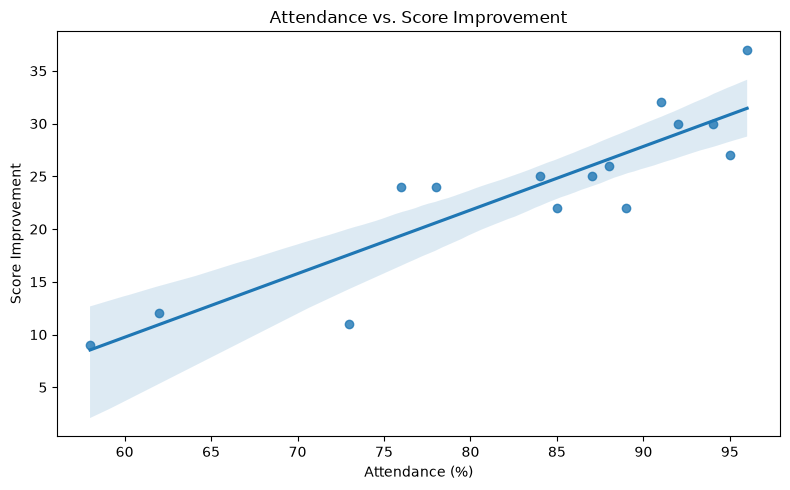

In [43]:
# Examine the relationship between attendance and learning improvement

plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="attendance_pct",
    y="score_improvement"
)

plt.title("Attendance vs. Score Improvement")
plt.xlabel("Attendance (%)")
plt.ylabel("Score Improvement")

plt.tight_layout()
plt.show()

In [44]:
# Calculate average learning improvement by region

region_improvement = (
    df.groupby("region")["score_improvement"]
    .mean()
    .sort_values(ascending=False)
)

region_improvement

region
Eastern          29.666667
Greater Accra    25.500000
Central          21.666667
Western          20.500000
Ashanti          19.666667
Name: score_improvement, dtype: float64

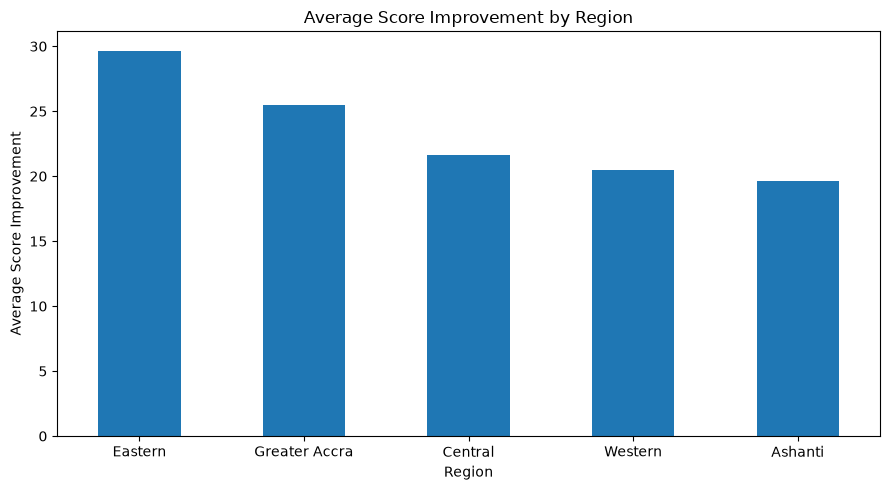

In [45]:
# Visualize average score improvement by region

plt.figure(figsize=(9, 5))

region_improvement.plot(kind="bar")

plt.title("Average Score Improvement by Region")
plt.xlabel("Region")
plt.ylabel("Average Score Improvement")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [46]:
# Calculate average participant satisfaction by training program

program_satisfaction = (
    df.groupby("program")["satisfaction"]
    .mean()
    .sort_values(ascending=False)
)

program_satisfaction

program
Data Analytics     4.333333
Cybersecurity      4.000000
Web Development    4.000000
Name: satisfaction, dtype: float64

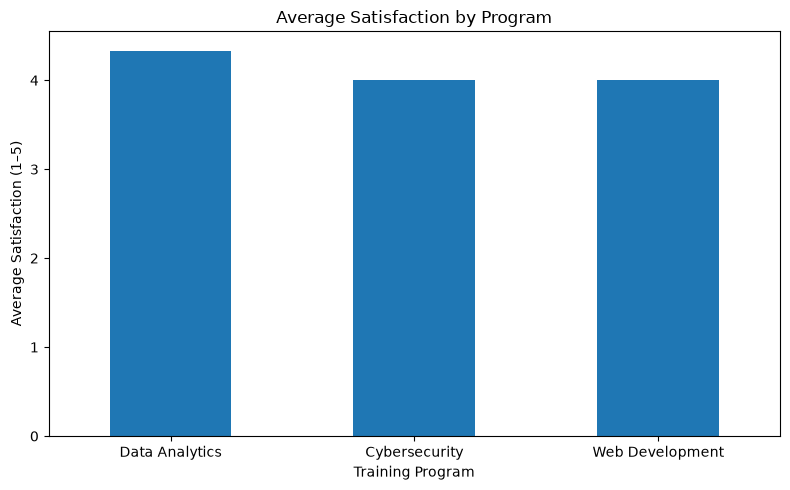

In [47]:
# Visualize participant satisfaction by training program

plt.figure(figsize=(8, 5))

program_satisfaction.plot(kind="bar")

plt.title("Average Satisfaction by Program")
plt.xlabel("Training Program")
plt.ylabel("Average Satisfaction (1–5)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [48]:
# Create a summary table of key program performance indicators

program_dashboard = df.groupby("program").agg(
    participants=("participant_id", "count"),
    average_attendance=("attendance_pct", "mean"),
    average_improvement=("score_improvement", "mean"),
    employment_rate=("employment_status",
                      lambda x: (x == "Employed").mean() * 100),
    average_satisfaction=("satisfaction", "mean")
).round(2)

program_dashboard

,participants,average_attendance,average_improvement,employment_rate,average_satisfaction
program,,,,,
Cybersecurity,4,84.75,22.0,75.00,4.00
Data Analytics,6,84.33,25.0,66.67,4.33
Web Development,5,80.60,23.6,60.00,4.00


In [49]:
# Create a summary table of regional performance

region_dashboard = df.groupby("region").agg(
    participants=("participant_id", "count"),
    average_attendance=("attendance_pct", "mean"),
    average_improvement=("score_improvement", "mean"),
    employment_rate=("employment_status",
                     lambda x: (x == "Employed").mean() * 100),
    average_satisfaction=("satisfaction", "mean")
).round(2)

region_dashboard

,participants,average_attendance,average_improvement,employment_rate,average_satisfaction
region,,,,,
Ashanti,3,77.00,19.67,66.67,3.67
Central,3,81.67,21.67,33.33,4.00
Eastern,3,92.67,29.67,100.00,4.67
Greater Accra,4,86.25,25.50,75.00,4.50
Western,2,74.50,20.50,50.00,3.50


In [50]:
# Compare key outcomes between employed and unemployed participants

employment_dashboard = df.groupby("employment_status").agg(
    participants=("participant_id", "count"),
    average_attendance=("attendance_pct", "mean"),
    average_improvement=("score_improvement", "mean"),
    average_satisfaction=("satisfaction", "mean")
).round(2)

employment_dashboard

,participants,average_attendance,average_improvement,average_satisfaction
employment_status,,,,
Employed,10,90.1,27.6,4.6
Unemployed,5,69.4,16.0,3.2


In [51]:
# Display the main DTI project KPIs

print("=" * 60)
print("        YOUTH SKILLS PROGRAM — PERFORMANCE DASHBOARD")
print("=" * 60)

print(f"Total Participants:       {len(df)}")
print(f"Average Attendance:       {df['attendance_pct'].mean():.1f}%")
print(f"Average Score Improvement:{df['score_improvement'].mean():.2f}")
print(f"Employment Rate:          {(df['employment_status'].eq('Employed').mean() * 100):.1f}%")
print(f"Average Satisfaction:     {df['satisfaction'].mean():.2f}/5")
print(f"Needs Attention:         {(df['performance_flag'].eq('Needs Attention').mean() * 100):.1f}%")

        YOUTH SKILLS PROGRAM — PERFORMANCE DASHBOARD
Total Participants:       15
Average Attendance:       83.2%
Average Score Improvement:23.73
Employment Rate:          66.7%
Average Satisfaction:     4.13/5
Needs Attention:         20.0%


In [52]:
# Export dashboard-ready summary datasets

program_dashboard.to_csv("../data/program_dashboard.csv")
region_dashboard.to_csv("../data/region_dashboard.csv")
employment_dashboard.to_csv("../data/employment_dashboard.csv")

print("Dashboard datasets exported successfully.")

Dashboard datasets exported successfully.


In [53]:
# Identify the strongest program outcomes

best_improvement_program = program_dashboard["average_improvement"].idxmax()
best_employment_program = program_dashboard["employment_rate"].idxmax()
best_satisfaction_program = program_dashboard["average_satisfaction"].idxmax()

print("Highest learning improvement:", best_improvement_program)
print("Highest employment rate:", best_employment_program)
print("Highest satisfaction:", best_satisfaction_program)

Highest learning improvement: Data Analytics
Highest employment rate: Cybersecurity
Highest satisfaction: Data Analytics


In [54]:
# Identify the strongest and weakest regions by learning improvement

best_region = region_dashboard["average_improvement"].idxmax()
lowest_region = region_dashboard["average_improvement"].idxmin()

print("Highest regional improvement:", best_region)
print("Lowest regional improvement:", lowest_region)

Highest regional improvement: Eastern
Lowest regional improvement: Ashanti


In [55]:
# Measure the relationship between attendance and score improvement

attendance_correlation = df["attendance_pct"].corr(
    df["score_improvement"]
)

print(f"Attendance vs improvement correlation: {attendance_correlation:.3f}")

Attendance vs improvement correlation: 0.894


In [56]:
# Count participants who meet the intervention criteria

needs_attention = df[
    df["performance_flag"] == "Needs Attention"
]

print(f"Participants needing attention: {len(needs_attention)}")
print(f"Percentage needing attention: {len(needs_attention) / len(df) * 100:.1f}%")

Participants needing attention: 3
Percentage needing attention: 20.0%
